✓ Saved heatmap_by_shape.png
✓ Saved heatmap_by_folder_and_shape.png


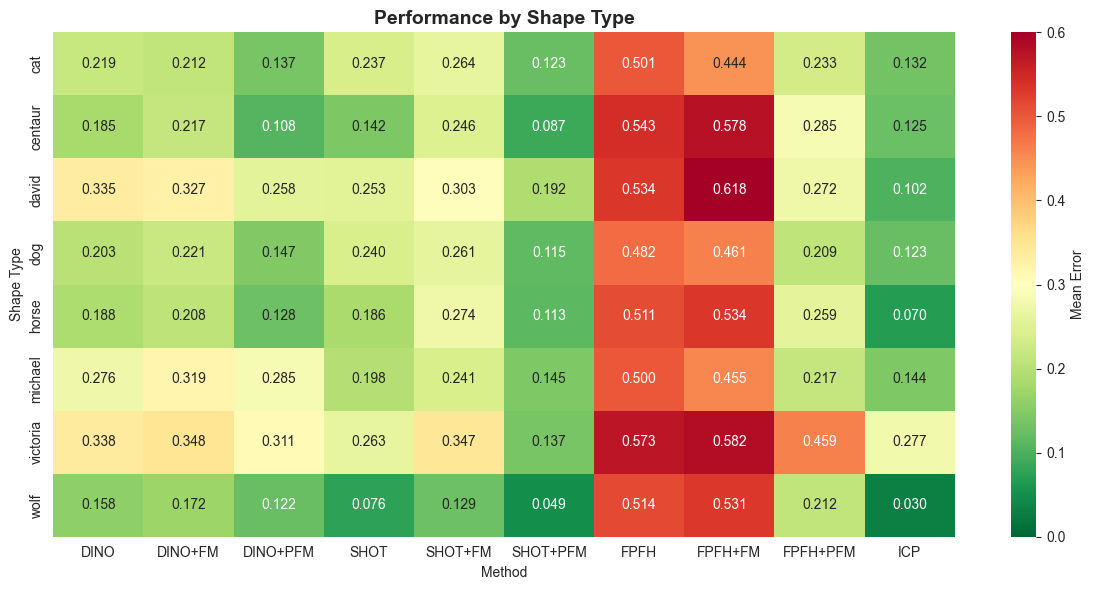

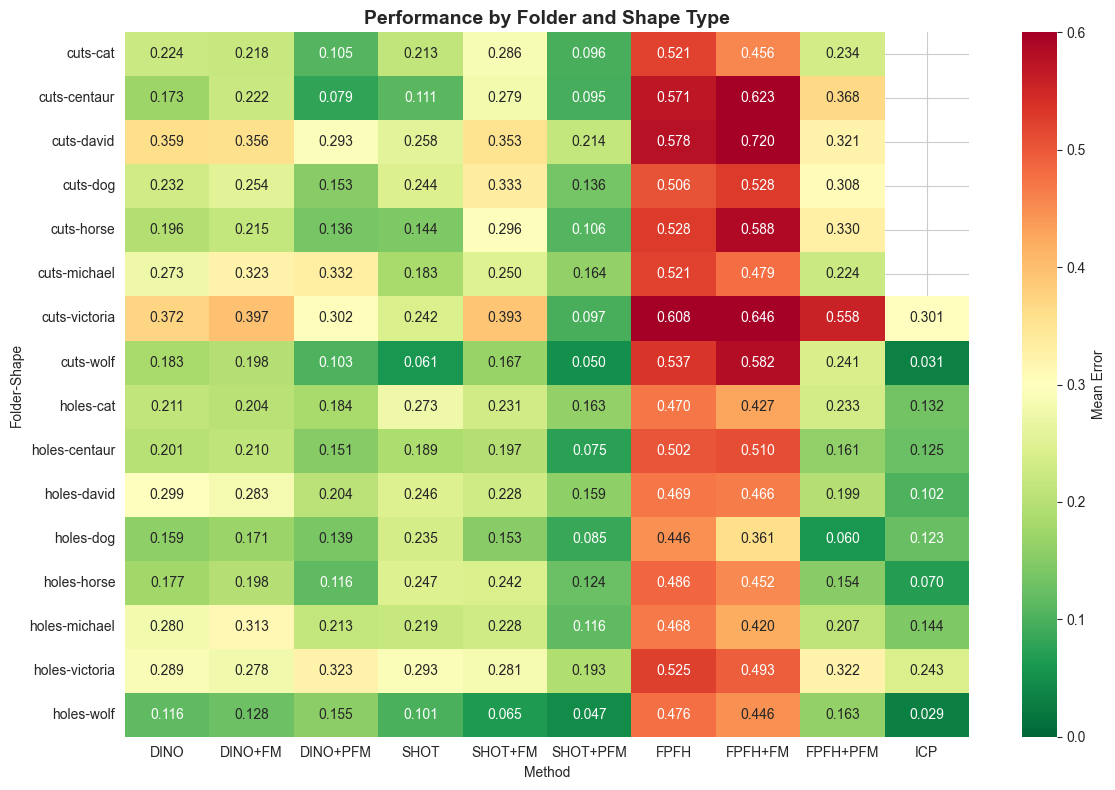

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = df[df['Mesh'] != '**Average**'].copy()
df['shape_type'] = df['Mesh'].str.extract(r'_(victoria|wolf|cat|michael|horse|dog|david|centaur)_')[0]

methods = ['DINO', 'DINO+FM', 'DINO+PFM', 'SHOT', 'SHOT+FM', 'SHOT+PFM', 
           'FPFH', 'FPFH+FM', 'FPFH+PFM', 'ICP']

for m in methods:
    df[m] = pd.to_numeric(df[m], errors='coerce')

# 1. Heatmap by shape type only
shape_performance = []
for shape in df['shape_type'].dropna().unique():
    subset = df[df['shape_type'] == shape]
    row = {'Shape': shape}
    for m in methods:
        row[m] = subset[m].mean()
    shape_performance.append(row)

perf_df = pd.DataFrame(shape_performance).set_index('Shape')

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(perf_df, annot=True, fmt='.3f', cmap='RdYlGn_r', ax=ax, 
            cbar_kws={'label': 'Mean Error'}, vmin=0, vmax=0.6)
ax.set_title('Performance by Shape Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Method')
ax.set_ylabel('Shape Type')
plt.tight_layout()
plt.savefig('heatmap_by_shape.png', dpi=300, bbox_inches='tight')
print("✓ Saved heatmap_by_shape.png")

# 2. Heatmap by folder AND shape type
folder_shape_performance = []
for folder in df['Folder'].unique():
    for shape in df[df['Folder'] == folder]['shape_type'].dropna().unique():
        subset = df[(df['Folder'] == folder) & (df['shape_type'] == shape)]
        row = {'Folder-Shape': f"{folder}-{shape}"}
        for m in methods:
            row[m] = subset[m].mean()
        folder_shape_performance.append(row)

perf_df2 = pd.DataFrame(folder_shape_performance).set_index('Folder-Shape')

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(perf_df2, annot=True, fmt='.3f', cmap='RdYlGn_r', ax=ax, 
            cbar_kws={'label': 'Mean Error'}, vmin=0, vmax=0.6)
ax.set_title('Performance by Folder and Shape Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Method')
ax.set_ylabel('Folder-Shape')
plt.tight_layout()
plt.savefig('heatmap_by_folder_and_shape.png', dpi=300, bbox_inches='tight')
print("✓ Saved heatmap_by_folder_and_shape.png")

plt.show()

In [3]:

import json
import sys

def load_benchmark_data(json_file):
    """Load benchmark data from JSON file"""
    with open(json_file, 'r') as f:
        return json.load(f)

def analyze_pfm_comparison(data):
    """Compare DINO PFM vs SHOT PFM errors"""
    dino_better = []
    shot_better = []
    ties = []
    
    for entry in data:
        name = entry['name']
        dino_pfm = entry['dino_pfm_error']
        shot_pfm = entry['shot_pfm_error']
        
        if dino_pfm < shot_pfm:
            dino_better.append((name, dino_pfm, shot_pfm, shot_pfm - dino_pfm))
        elif shot_pfm < dino_pfm:
            shot_better.append((name, shot_pfm, dino_pfm, dino_pfm - shot_pfm))
        else:
            ties.append((name, dino_pfm, shot_pfm))
    
    return dino_better, shot_better, ties

def print_summary(dino_better, shot_better, ties, total):
    """Print summary statistics"""
    print("="*80)
    print("PFM ERROR COMPARISON: DINO vs SHOT")
    print("="*80)
    print(f"\nTotal cases: {total}")
    print(f"  DINO+PFM better: {len(dino_better)} ({100*len(dino_better)/total:.1f}%)")
    print(f"  SHOT+PFM better: {len(shot_better)} ({100*len(shot_better)/total:.1f}%)")
    print(f"  Ties: {len(ties)} ({100*len(ties)/total:.1f}%)")

def print_top_cases(dino_better, shot_better, n=10):
    """Print top N cases for each category"""
    print("\n" + "="*80)
    print(f"TOP {n}: DINO+PFM BETTER (largest margins)")
    print("="*80)
    for name, dino, shot, margin in sorted(dino_better, key=lambda x: x[3], reverse=True)[:n]:
        print(f"{name:35s}  DINO={dino:.4f}  SHOT={shot:.4f}  margin={margin:.4f}")
    
    print("\n" + "="*80)
    print(f"TOP {n}: SHOT+PFM BETTER (largest margins)")
    print("="*80)
    for name, shot, dino, margin in sorted(shot_better, key=lambda x: x[3], reverse=True)[:n]:
        print(f"{name:35s}  SHOT={shot:.4f}  DINO={dino:.4f}  margin={margin:.4f}")

def save_full_report(dino_better, shot_better, ties, total, output_file):
    """Save detailed report to file"""
    with open(output_file, 'w') as f:
        f.write("="*80 + "\n")
        f.write("COMPLETE PFM ERROR COMPARISON: DINO vs SHOT\n")
        f.write("="*80 + "\n\n")
        
        f.write(f"SUMMARY:\n")
        f.write(f"  Total cases: {total}\n")
        f.write(f"  DINO+PFM better: {len(dino_better)} ({100*len(dino_better)/total:.1f}%)\n")
        f.write(f"  SHOT+PFM better: {len(shot_better)} ({100*len(shot_better)/total:.1f}%)\n")
        f.write(f"  Ties: {len(ties)} ({100*len(ties)/total:.1f}%)\n\n")
        
        f.write("="*80 + "\n")
        f.write("ALL CASES WHERE DINO+PFM IS BETTER (sorted by margin)\n")
        f.write("="*80 + "\n\n")
        for name, dino, shot, margin in sorted(dino_better, key=lambda x: x[3], reverse=True):
            f.write(f"{name}\n")
            f.write(f"  DINO PFM: {dino:.4f}\n")
            f.write(f"  SHOT PFM: {shot:.4f}\n")
            f.write(f"  Margin: {margin:.4f}\n\n")
        
        f.write("="*80 + "\n")
        f.write("ALL CASES WHERE SHOT+PFM IS BETTER (sorted by margin)\n")
        f.write("="*80 + "\n\n")
        for name, shot, dino, margin in sorted(shot_better, key=lambda x: x[3], reverse=True):
            f.write(f"{name}\n")
            f.write(f"  SHOT PFM: {shot:.4f}\n")
            f.write(f"  DINO PFM: {dino:.4f}\n")
            f.write(f"  Margin: {margin:.4f}\n\n")
        
        f.write("="*80 + "\n")
        f.write("TIES (equal performance)\n")
        f.write("="*80 + "\n\n")
        for name, dino, shot in ties:
            f.write(f"{name}: {dino:.4f}\n")

def compute_statistics(dino_better, shot_better):
    """Compute additional statistics"""
    if dino_better:
        dino_margins = [m for _, _, _, m in dino_better]
        dino_avg = sum(dino_margins) / len(dino_margins)
        dino_max = max(dino_margins)
    else:
        dino_avg = dino_max = 0
    
    if shot_better:
        shot_margins = [m for _, _, _, m in shot_better]
        shot_avg = sum(shot_margins) / len(shot_margins)
        shot_max = max(shot_margins)
    else:
        shot_avg = shot_max = 0
    
    print("\n" + "="*80)
    print("STATISTICS")
    print("="*80)
    print(f"When DINO wins:")
    print(f"  Average margin: {dino_avg:.4f}")
    print(f"  Maximum margin: {dino_max:.4f}")
    print(f"\nWhen SHOT wins:")
    print(f"  Average margin: {shot_avg:.4f}")
    print(f"  Maximum margin: {shot_max:.4f}")


    
input_file = "benchmark_results.json"
output_file = "pfm_comparison_report.txt"

# Load data
print(f"Loading data from {input_file}...")
data = load_benchmark_data(input_file)

# Analyze
dino_better, shot_better, ties = analyze_pfm_comparison(data)
total = len(data)

# Print results
print_summary(dino_better, shot_better, ties, total)
print_top_cases(dino_better, shot_better, n=10)
compute_statistics(dino_better, shot_better)

# Save report
save_full_report(dino_better, shot_better, ties, total, output_file)
print(f"\n\nFull report saved to: {output_file}")



Loading data from benchmark_results.json...
PFM ERROR COMPARISON: DINO vs SHOT

Total cases: 198
  DINO+PFM better: 67 (33.8%)
  SHOT+PFM better: 114 (57.6%)
  Ties: 17 (8.6%)

TOP 10: DINO+PFM BETTER (largest margins)
cuts_centaur_shape_2                 DINO=0.0030  SHOT=0.7768  margin=0.7738
cuts_horse_shape_13                  DINO=0.0820  SHOT=0.6850  margin=0.6030
cuts_david_shape_7                   DINO=0.2031  SHOT=0.7535  margin=0.5504
cuts_david_shape_6                   DINO=0.0230  SHOT=0.5067  margin=0.4837
cuts_michael_shape_10                DINO=0.1851  SHOT=0.5632  margin=0.3781
cuts_dog_shape_3                     DINO=0.2986  SHOT=0.6481  margin=0.3495
cuts_michael_shape_15                DINO=0.0251  SHOT=0.3367  margin=0.3116
cuts_cat_shape_10                    DINO=0.0362  SHOT=0.3397  margin=0.3035
cuts_victoria_shape_9                DINO=0.0948  SHOT=0.3951  margin=0.3002
cuts_david_shape_1                   DINO=0.0042  SHOT=0.2212  margin=0.2170

TOP 10: SH

In [4]:
#!/usr/bin/env python3
"""
Top Performer Distribution Analysis
Counts how many times each method (DINO, SHOT, FPFH) is the best performer
"""

import json
import sys
from collections import defaultdict

def load_benchmark_data(json_file):
    """Load benchmark data from JSON file"""
    with open(json_file, 'r') as f:
        return json.load(f)

def find_best_method(entry, metric):
    """Find which method has lowest error for given metric"""
    errors = {
        'DINO': entry.get(f'dino_{metric}'),
        'SHOT': entry.get(f'shot_{metric}'),
        'FPFH': entry.get(f'fpfh_{metric}')
    }
    
    # Filter out None values
    valid_errors = {k: v for k, v in errors.items() if v is not None}
    
    if not valid_errors:
        return None, None
    
    best_method = min(valid_errors, key=valid_errors.get)
    best_error = valid_errors[best_method]
    
    return best_method, best_error

def analyze_top_performers(data):
    """Count how many times each method is the best performer"""
    metrics = ['argmax_error', 'fm_error', 'pfm_error']
    
    # Overall counts
    overall_counts = {metric: defaultdict(int) for metric in metrics}
    
    # By dataset
    cuts_counts = {metric: defaultdict(int) for metric in metrics}
    holes_counts = {metric: defaultdict(int) for metric in metrics}
    
    # Store details for each case
    winners = {metric: [] for metric in metrics}
    
    for entry in data:
        name = entry['name']
        folder = entry['folder']
        
        for metric in metrics:
            best_method, best_error = find_best_method(entry, metric)
            
            if best_method:
                # Overall
                overall_counts[metric][best_method] += 1
                
                # By dataset
                if folder == 'cuts':
                    cuts_counts[metric][best_method] += 1
                else:
                    holes_counts[metric][best_method] += 1
                
                # Store winner
                all_errors = {
                    'DINO': entry.get(f'dino_{metric}'),
                    'SHOT': entry.get(f'shot_{metric}'),
                    'FPFH': entry.get(f'fpfh_{metric}')
                }
                winners[metric].append({
                    'name': name,
                    'folder': folder,
                    'winner': best_method,
                    'errors': all_errors
                })
    
    return overall_counts, cuts_counts, holes_counts, winners

def print_distribution(counts, title):
    """Print distribution of winners"""
    print(f"\n{title}")
    print("="*80)
    
    for metric in ['argmax_error', 'fm_error', 'pfm_error']:
        print(f"\n{metric.upper().replace('_', ' ')}:")
        metric_total = sum(counts[metric].values())
        
        # Sort by count descending
        sorted_methods = sorted(counts[metric].items(), key=lambda x: x[1], reverse=True)
        
        for method, count in sorted_methods:
            if metric_total > 0:
                pct = 100 * count / metric_total
                bar = '█' * int(pct / 2)
                print(f"  {method:5s}: {count:3d} / {metric_total:3d} ({pct:5.1f}%)  {bar}")

def print_overall_summary(overall_counts):
    """Print overall summary across all metrics"""
    print("\n" + "="*80)
    print("OVERALL SUMMARY (Across All Metrics)")
    print("="*80)
    
    totals = defaultdict(int)
    total_cases = 0
    
    for metric in ['argmax_error', 'fm_error', 'pfm_error']:
        for method, count in overall_counts[metric].items():
            totals[method] += count
            total_cases += count
    
    print(f"\nTotal comparisons: {total_cases}")
    print(f"\nMethod Wins:")
    
    sorted_totals = sorted(totals.items(), key=lambda x: x[1], reverse=True)
    for method, count in sorted_totals:
        pct = 100 * count / total_cases if total_cases > 0 else 0
        bar = '█' * int(pct / 2)
        print(f"  {method:5s}: {count:3d} ({pct:5.1f}%)  {bar}")

def save_detailed_report(overall_counts, cuts_counts, holes_counts, winners, output_file):
    """Save detailed report"""
    with open(output_file, 'w') as f:
        f.write("="*80 + "\n")
        f.write("TOP PERFORMER DISTRIBUTION ANALYSIS\n")
        f.write("="*80 + "\n\n")
        
        # Overall summary
        f.write("OVERALL SUMMARY (Across All Metrics)\n")
        f.write("-"*80 + "\n")
        totals = defaultdict(int)
        total_cases = 0
        for metric in ['argmax_error', 'fm_error', 'pfm_error']:
            for method, count in overall_counts[metric].items():
                totals[method] += count
                total_cases += count
        
        f.write(f"Total comparisons: {total_cases}\n\n")
        sorted_totals = sorted(totals.items(), key=lambda x: x[1], reverse=True)
        for method, count in sorted_totals:
            pct = 100 * count / total_cases if total_cases > 0 else 0
            f.write(f"  {method}: {count} ({pct:.1f}%)\n")
        
        # Overall by metric
        f.write("\n" + "="*80 + "\n")
        f.write("OVERALL DISTRIBUTION BY METRIC\n")
        f.write("="*80 + "\n")
        for metric in ['argmax_error', 'fm_error', 'pfm_error']:
            f.write(f"\n{metric.upper().replace('_', ' ')}:\n")
            metric_total = sum(overall_counts[metric].values())
            sorted_methods = sorted(overall_counts[metric].items(), key=lambda x: x[1], reverse=True)
            for method, count in sorted_methods:
                pct = 100 * count / metric_total if metric_total > 0 else 0
                f.write(f"  {method}: {count} / {metric_total} ({pct:.1f}%)\n")
        
        # Cuts dataset
        f.write("\n" + "="*80 + "\n")
        f.write("CUTS DATASET\n")
        f.write("="*80 + "\n")
        for metric in ['argmax_error', 'fm_error', 'pfm_error']:
            f.write(f"\n{metric.upper().replace('_', ' ')}:\n")
            metric_total = sum(cuts_counts[metric].values())
            sorted_methods = sorted(cuts_counts[metric].items(), key=lambda x: x[1], reverse=True)
            for method, count in sorted_methods:
                pct = 100 * count / metric_total if metric_total > 0 else 0
                f.write(f"  {method}: {count} / {metric_total} ({pct:.1f}%)\n")
        
        # Holes dataset
        f.write("\n" + "="*80 + "\n")
        f.write("HOLES DATASET\n")
        f.write("="*80 + "\n")
        for metric in ['argmax_error', 'fm_error', 'pfm_error']:
            f.write(f"\n{metric.upper().replace('_', ' ')}:\n")
            metric_total = sum(holes_counts[metric].values())
            sorted_methods = sorted(holes_counts[metric].items(), key=lambda x: x[1], reverse=True)
            for method, count in sorted_methods:
                pct = 100 * count / metric_total if metric_total > 0 else 0
                f.write(f"  {method}: {count} / {metric_total} ({pct:.1f}%)\n")
        
        # Detailed case-by-case for each metric
        for metric in ['argmax_error', 'fm_error', 'pfm_error']:
            f.write("\n" + "="*80 + "\n")
            f.write(f"DETAILED RESULTS: {metric.upper().replace('_', ' ')}\n")
            f.write("="*80 + "\n\n")
            
            for case in winners[metric]:
                f.write(f"{case['name']} ({case['folder']})\n")
                f.write(f"  Winner: {case['winner']}\n")
                f.write(f"  Errors: DINO={case['errors']['DINO']:.4f}, "
                       f"SHOT={case['errors']['SHOT']:.4f}, "
                       f"FPFH={case['errors']['FPFH']:.4f}\n\n")


input_file = "benchmark_results.json"
output_file = "top_performer_report.txt"

# Load data
print(f"Loading data from {input_file}...")
data = load_benchmark_data(input_file)
print(f"Loaded {len(data)} benchmark cases")

# Analyze
overall_counts, cuts_counts, holes_counts, winners = analyze_top_performers(data)

# Print results
print_overall_summary(overall_counts)
print_distribution(overall_counts, "OVERALL DISTRIBUTION BY METRIC")
print_distribution(cuts_counts, "CUTS DATASET")
print_distribution(holes_counts, "HOLES DATASET")

# Save report
save_detailed_report(overall_counts, cuts_counts, holes_counts, winners, output_file)
print(f"\n\nDetailed report saved to: {output_file}")



Loading data from benchmark_results.json...
Loaded 198 benchmark cases

OVERALL SUMMARY (Across All Metrics)

Total comparisons: 594

Method Wins:
  SHOT : 304 ( 51.2%)  █████████████████████████
  DINO : 256 ( 43.1%)  █████████████████████
  FPFH :  34 (  5.7%)  ██

OVERALL DISTRIBUTION BY METRIC

ARGMAX ERROR:
  SHOT : 116 / 198 ( 58.6%)  █████████████████████████████
  DINO :  82 / 198 ( 41.4%)  ████████████████████

FM ERROR:
  DINO : 101 / 198 ( 51.0%)  █████████████████████████
  SHOT :  96 / 198 ( 48.5%)  ████████████████████████
  FPFH :   1 / 198 (  0.5%)  

PFM ERROR:
  SHOT :  92 / 198 ( 46.5%)  ███████████████████████
  DINO :  73 / 198 ( 36.9%)  ██████████████████
  FPFH :  33 / 198 ( 16.7%)  ████████

CUTS DATASET

ARGMAX ERROR:
  SHOT :  83 / 119 ( 69.7%)  ██████████████████████████████████
  DINO :  36 / 119 ( 30.3%)  ███████████████

FM ERROR:
  DINO :  71 / 119 ( 59.7%)  █████████████████████████████
  SHOT :  48 / 119 ( 40.3%)  ████████████████████

PFM ERROR:
  DINO

In [6]:
#!/usr/bin/env python3
"""
Sub-Method Analysis with Margins
Analyzes which descriptor+method combination performs best and by what margin
"""

import json
from collections import defaultdict

def load_benchmark_data(json_file):
    """Load benchmark data from JSON file"""
    with open(json_file, 'r') as f:
        return json.load(f)

def find_best_submethod(entry):
    """Find which descriptor+method combination has lowest error"""
    submethods = {
        'DINO+argmax': entry.get('dino_argmax_error'),
        'DINO+FM': entry.get('dino_fm_error'),
        'DINO+PFM': entry.get('dino_pfm_error'),
        'SHOT+argmax': entry.get('shot_argmax_error'),
        'SHOT+FM': entry.get('shot_fm_error'),
        'SHOT+PFM': entry.get('shot_pfm_error'),
        'FPFH+argmax': entry.get('fpfh_argmax_error'),
        'FPFH+FM': entry.get('fpfh_fm_error'),
        'FPFH+PFM': entry.get('fpfh_pfm_error'),
    }
    
    # Filter out None values
    valid = {k: v for k, v in submethods.items() if v is not None}
    
    if not valid:
        return None, None, None, None
    
    # Sort by error value
    sorted_methods = sorted(valid.items(), key=lambda x: x[1])
    
    best = sorted_methods[0][0]
    best_error = sorted_methods[0][1]
    
    # Calculate margin to second best
    if len(sorted_methods) > 1:
        second_best_error = sorted_methods[1][1]
        margin = second_best_error - best_error
    else:
        margin = None
    
    return best, best_error, margin, valid

def analyze_submethods(data):
    """Analyze which sub-methods perform best"""
    overall_counts = defaultdict(int)
    cuts_counts = defaultdict(int)
    holes_counts = defaultdict(int)
    
    # Track margins for each winning method
    margins_by_method = defaultdict(list)
    
    winners = []
    
    for entry in data:
        name = entry['name']
        folder = entry['folder']
        
        best, best_error, margin, all_errors = find_best_submethod(entry)
        
        if best:
            # Overall
            overall_counts[best] += 1
            
            # By dataset
            if folder == 'cuts':
                cuts_counts[best] += 1
            else:
                holes_counts[best] += 1
            
            # Track margin
            if margin is not None:
                margins_by_method[best].append(margin)
            
            # Store details
            winners.append({
                'name': name,
                'folder': folder,
                'winner': best,
                'winner_error': best_error,
                'margin': margin,
                'all_errors': all_errors
            })
    
    return overall_counts, cuts_counts, holes_counts, margins_by_method, winners

def print_distribution(counts, margins, title, total):
    """Print distribution of winners with average margins"""
    print(f"\n{title}")
    print("="*80)
    
    if total == 0:
        print("  No data")
        return
    
    # Sort by count descending
    sorted_methods = sorted(counts.items(), key=lambda x: x[1], reverse=True)
    
    for method, count in sorted_methods:
        pct = 100 * count / total
        bar = '█' * int(pct / 2)
        
        # Calculate average margin
        if method in margins and margins[method]:
            avg_margin = sum(margins[method]) / len(margins[method])
            margin_str = f"avg_margin={avg_margin:.4f}"
        else:
            margin_str = "avg_margin=N/A"
        
        print(f"  {method:15s}: {count:3d} / {total:3d} ({pct:5.1f}%)  {margin_str:20s}  {bar}")

def print_overall_summary(overall_counts, margins_by_method):
    """Print overall summary"""
    print("\n" + "="*80)
    print("OVERALL RESULTS: Best Sub-Method Performance")
    print("="*80)
    
    total = sum(overall_counts.values())
    print(f"\nTotal cases: {total}")
    print(f"\nSub-Method Wins (sorted by frequency):")
    print(f"{'Method':<15s} {'Count':>5s} {'Pct':>6s} {'Avg Margin':>12s} {'Min':>8s} {'Max':>8s}")
    print("-" * 80)
    
    sorted_counts = sorted(overall_counts.items(), key=lambda x: x[1], reverse=True)
    for method, count in sorted_counts:
        pct = 100 * count / total if total > 0 else 0
        
        if method in margins_by_method and margins_by_method[method]:
            margins = margins_by_method[method]
            avg_margin = sum(margins) / len(margins)
            min_margin = min(margins)
            max_margin = max(margins)
            bar = '█' * int(pct / 2)
            print(f"{method:15s} {count:5d} {pct:5.1f}%  {avg_margin:10.4f}  {min_margin:8.4f} {max_margin:8.4f}  {bar}")
        else:
            bar = '█' * int(pct / 2)
            print(f"{method:15s} {count:5d} {pct:5.1f}%  {'N/A':>10s}  {'N/A':>8s} {'N/A':>8s}  {bar}")

def aggregate_by_descriptor(overall_counts, margins_by_method):
    """Aggregate results by descriptor (DINO, SHOT, FPFH)"""
    print("\n" + "="*80)
    print("AGGREGATED BY DESCRIPTOR")
    print("="*80)
    
    desc_totals = defaultdict(int)
    desc_margins = defaultdict(list)
    total = sum(overall_counts.values())
    
    for method, count in overall_counts.items():
        desc = method.split('+')[0]
        desc_totals[desc] += count
        if method in margins_by_method:
            desc_margins[desc].extend(margins_by_method[method])
    
    sorted_desc = sorted(desc_totals.items(), key=lambda x: x[1], reverse=True)
    print(f"{'Descriptor':<10s} {'Count':>5s} {'Pct':>6s} {'Avg Margin':>12s}")
    print("-" * 50)
    for desc, count in sorted_desc:
        pct = 100 * count / total if total > 0 else 0
        bar = '█' * int(pct / 2)
        
        if desc_margins[desc]:
            avg_margin = sum(desc_margins[desc]) / len(desc_margins[desc])
            print(f"{desc:10s} {count:5d} {pct:5.1f}%  {avg_margin:10.4f}  {bar}")
        else:
            print(f"{desc:10s} {count:5d} {pct:5.1f}%  {'N/A':>10s}  {bar}")

def aggregate_by_method(overall_counts, margins_by_method):
    """Aggregate results by method type (argmax, FM, PFM)"""
    print("\n" + "="*80)
    print("AGGREGATED BY METHOD TYPE")
    print("="*80)
    
    method_totals = defaultdict(int)
    method_margins = defaultdict(list)
    total = sum(overall_counts.values())
    
    for submethod, count in overall_counts.items():
        method = submethod.split('+')[1]
        method_totals[method] += count
        if submethod in margins_by_method:
            method_margins[method].extend(margins_by_method[submethod])
    
    sorted_methods = sorted(method_totals.items(), key=lambda x: x[1], reverse=True)
    print(f"{'Method':<10s} {'Count':>5s} {'Pct':>6s} {'Avg Margin':>12s}")
    print("-" * 50)
    for method, count in sorted_methods:
        pct = 100 * count / total if total > 0 else 0
        bar = '█' * int(pct / 2)
        
        if method_margins[method]:
            avg_margin = sum(method_margins[method]) / len(method_margins[method])
            print(f"{method:10s} {count:5d} {pct:5.1f}%  {avg_margin:10.4f}  {bar}")
        else:
            print(f"{method:10s} {count:5d} {pct:5.1f}%  {'N/A':>10s}  {bar}")

def save_detailed_report(overall_counts, cuts_counts, holes_counts, margins_by_method, winners, output_file):
    """Save detailed report"""
    with open(output_file, 'w') as f:
        f.write("="*80 + "\n")
        f.write("SUB-METHOD PERFORMANCE ANALYSIS WITH MARGINS\n")
        f.write("="*80 + "\n\n")
        
        total = sum(overall_counts.values())
        
        # Overall distribution
        f.write("OVERALL DISTRIBUTION\n")
        f.write("-"*80 + "\n")
        f.write(f"Total cases: {total}\n\n")
        f.write(f"{'Method':<15s} {'Count':>5s} {'Pct':>6s} {'Avg Margin':>12s} {'Min Margin':>12s} {'Max Margin':>12s}\n")
        f.write("-"*80 + "\n")
        
        sorted_counts = sorted(overall_counts.items(), key=lambda x: x[1], reverse=True)
        for method, count in sorted_counts:
            pct = 100 * count / total if total > 0 else 0
            
            if method in margins_by_method and margins_by_method[method]:
                margins = margins_by_method[method]
                avg_margin = sum(margins) / len(margins)
                min_margin = min(margins)
                max_margin = max(margins)
                f.write(f"{method:15s} {count:5d} {pct:5.1f}%  {avg_margin:10.4f}  {min_margin:12.4f}  {max_margin:12.4f}\n")
            else:
                f.write(f"{method:15s} {count:5d} {pct:5.1f}%  {'N/A':>10s}  {'N/A':>12s}  {'N/A':>12s}\n")
        
        # By descriptor
        f.write("\n" + "="*80 + "\n")
        f.write("AGGREGATED BY DESCRIPTOR\n")
        f.write("-"*80 + "\n")
        desc_totals = defaultdict(int)
        desc_margins = defaultdict(list)
        for method, count in overall_counts.items():
            desc = method.split('+')[0]
            desc_totals[desc] += count
            if method in margins_by_method:
                desc_margins[desc].extend(margins_by_method[method])
        
        sorted_desc = sorted(desc_totals.items(), key=lambda x: x[1], reverse=True)
        for desc, count in sorted_desc:
            pct = 100 * count / total if total > 0 else 0
            if desc_margins[desc]:
                avg_margin = sum(desc_margins[desc]) / len(desc_margins[desc])
                f.write(f"  {desc}: {count} ({pct:.1f}%), avg_margin={avg_margin:.4f}\n")
            else:
                f.write(f"  {desc}: {count} ({pct:.1f}%), avg_margin=N/A\n")
        
        # By method type
        f.write("\n" + "="*80 + "\n")
        f.write("AGGREGATED BY METHOD TYPE\n")
        f.write("-"*80 + "\n")
        method_totals = defaultdict(int)
        method_margins = defaultdict(list)
        for submethod, count in overall_counts.items():
            method = submethod.split('+')[1]
            method_totals[method] += count
            if submethod in margins_by_method:
                method_margins[method].extend(margins_by_method[submethod])
        
        sorted_methods = sorted(method_totals.items(), key=lambda x: x[1], reverse=True)
        for method, count in sorted_methods:
            pct = 100 * count / total if total > 0 else 0
            if method_margins[method]:
                avg_margin = sum(method_margins[method]) / len(method_margins[method])
                f.write(f"  {method}: {count} ({pct:.1f}%), avg_margin={avg_margin:.4f}\n")
            else:
                f.write(f"  {method}: {count} ({pct:.1f}%), avg_margin=N/A\n")
        
        # Cuts dataset
        f.write("\n" + "="*80 + "\n")
        f.write("CUTS DATASET\n")
        f.write("="*80 + "\n\n")
        cuts_total = sum(cuts_counts.values())
        sorted_cuts = sorted(cuts_counts.items(), key=lambda x: x[1], reverse=True)
        for method, count in sorted_cuts:
            pct = 100 * count / cuts_total if cuts_total > 0 else 0
            f.write(f"  {method:15s}: {count:3d} / {cuts_total:3d} ({pct:5.1f}%)\n")
        
        # Holes dataset
        f.write("\n" + "="*80 + "\n")
        f.write("HOLES DATASET\n")
        f.write("="*80 + "\n\n")
        holes_total = sum(holes_counts.values())
        sorted_holes = sorted(holes_counts.items(), key=lambda x: x[1], reverse=True)
        for method, count in sorted_holes:
            pct = 100 * count / holes_total if holes_total > 0 else 0
            f.write(f"  {method:15s}: {count:3d} / {holes_total:3d} ({pct:5.1f}%)\n")
        
        # Detailed case-by-case
        f.write("\n" + "="*80 + "\n")
        f.write("DETAILED CASE-BY-CASE RESULTS\n")
        f.write("="*80 + "\n\n")
        
        for case in winners:
            f.write(f"{case['name']} ({case['folder']})\n")
            f.write(f"  Winner: {case['winner']} = {case['winner_error']:.4f}")
            if case['margin'] is not None:
                f.write(f" (margin over 2nd: {case['margin']:.4f})\n")
            else:
                f.write(" (margin: N/A)\n")
            f.write(f"  All errors:\n")
            
            # Sort errors for display
            sorted_errors = sorted(case['all_errors'].items(), key=lambda x: x[1])
            for i, (method, error) in enumerate(sorted_errors):
                if i == 0:
                    marker = " <-- BEST"
                elif i == 1 and case['margin'] is not None:
                    marker = f" <-- 2nd (Δ={case['margin']:.4f})"
                else:
                    marker = ""
                f.write(f"    {method:15s}: {error:.4f}{marker}\n")
            f.write("\n")
        
        # Group by winner with margin statistics
        f.write("\n" + "="*80 + "\n")
        f.write("CASES GROUPED BY WINNING SUB-METHOD\n")
        f.write("="*80 + "\n\n")
        
        by_winner = defaultdict(list)
        for case in winners:
            by_winner[case['winner']].append(case)
        
        for method in sorted(by_winner.keys()):
            cases = by_winner[method]
            margins = [c['margin'] for c in cases if c['margin'] is not None]
            
            f.write(f"{method} ({len(cases)} cases")
            if margins:
                avg_margin = sum(margins) / len(margins)
                f.write(f", avg_margin={avg_margin:.4f}):\n")
            else:
                f.write(f"):\n")
            
            for case in cases:
                margin_str = f"margin={case['margin']:.4f}" if case['margin'] is not None else "margin=N/A"
                f.write(f"  {case['name']:40s} error={case['winner_error']:.4f}, {margin_str}\n")
            f.write("\n")


# Main execution
input_file = "benchmark_results.json"
output_file = "submethod_analysis_report.txt"

# Load data
print(f"Loading data from {input_file}...")
data = load_benchmark_data(input_file)
print(f"Loaded {len(data)} benchmark cases")

# Analyze
overall_counts, cuts_counts, holes_counts, margins_by_method, winners = analyze_submethods(data)

# Print results
print_overall_summary(overall_counts, margins_by_method)
aggregate_by_descriptor(overall_counts, margins_by_method)
aggregate_by_method(overall_counts, margins_by_method)

print_distribution(cuts_counts, margins_by_method, "CUTS DATASET", sum(cuts_counts.values()))
print_distribution(holes_counts, margins_by_method, "HOLES DATASET", sum(holes_counts.values()))

# Save report
save_detailed_report(overall_counts, cuts_counts, holes_counts, margins_by_method, winners, output_file)
print(f"\n\nDetailed report saved to: {output_file}")

Loading data from benchmark_results.json...
Loaded 198 benchmark cases

OVERALL RESULTS: Best Sub-Method Performance

Total cases: 198

Sub-Method Wins (sorted by frequency):
Method          Count    Pct   Avg Margin      Min      Max
--------------------------------------------------------------------------------
SHOT+PFM           82  41.4%      0.0629    0.0000   0.3487  ████████████████████
DINO+PFM           60  30.3%      0.0300    0.0000   0.2366  ███████████████
FPFH+PFM           31  15.7%      0.0455    0.0000   0.1732  ███████
SHOT+argmax        13   6.6%      0.0773    0.0040   0.2617  ███
DINO+FM             5   2.5%      0.0261    0.0074   0.0538  █
SHOT+FM             4   2.0%      0.0437    0.0295   0.0641  █
DINO+argmax         3   1.5%      0.0196    0.0006   0.0386  

AGGREGATED BY DESCRIPTOR
Descriptor Count    Pct   Avg Margin
--------------------------------------------------
SHOT          99  50.0%      0.0640  █████████████████████████
DINO          68  34.3%   